# Norman 2019 — Unified Model Evaluation + Top-20 Gene Visualization

Sections 1-7: CSV-based aggregate evaluation — **no model loading needed**.  
Section 8: Per-perturbation top-20 DE gene bar charts — **requires model loading**.

All models (scGPT vanilla, GRN-biased, GEARS) included in section 8 via a unified bundle interface.  
GEARS predictions are mapped from its full gene space → scGPT HVG space by gene name for aligned visualization.

In [1]:
#1.1 Imports
import sys, os, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
from scipy import sparse
from sklearn.linear_model import LinearRegression
from pathlib import Path
import torch
from torch import nn

try:
    import torchtext
    torchtext.disable_torchtext_deprecation_warning()
except Exception:
    pass

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
print(f'Device: {device}')
print('Imports OK')

Device: cuda
Imports OK


In [2]:
#1.2 CONFIG — edit this cell to add/remove models
# type: 'scgpt' or 'gears'
# GEARS entries additionally need gears_data_dir, gears_data_name, gears_split_seed
MODEL_CONFIGS = [
    {
        'save_dir': '../scGPT/save/dev_perturb_norman_leakfix-Mar05-20-28',
        'label': 'S1 scGPT vanilla',
        'color': '#2196F3',
        'type': 'scgpt',
    },
    {
        'save_dir': '../scGPT/save/dev_perturb_norman_grn_bias-Mar06-12-39',
        'label': 'S2 scGPT GRN bias',
        'color': '#FF9800',
        'type': 'scgpt',
    },
    {
        'save_dir': '../scGPT/save/norman_grn_bias_weight_v2-Mar06-17-21',
        'label': 'S2 scGPT v2',
        'color': '#4CAF50',
        'type': 'scgpt',
    },
    {
        'save_dir': '../GEARS/save/gears_norman_seed42-Mar06-16-35',
        'label': 'GEARS',
        'color': '#E91E63',
        'type': 'gears',
        'gears_data_dir': '../../data/raw_download/GEARS_data/',
        'gears_data_name': 'norman',
        'gears_split_seed': 42,
    },
]

DATA_PATH  = '../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad'
MODEL_DIR  = '../../model_checkpoints/scGPT_human'
OUT_DIR    = Path('./output')
OUT_DIR.mkdir(exist_ok=True)

GI_MAG_QUANTILE = 0.25
R2_NEOMORPHIC   = 0.5

# scGPT architecture constants (must match training)
EMBSIZE, D_HID, NLAYERS, NHEAD = 128, 512, 4, 4
N_LAYERS_CLS = 3
DROPOUT      = 0.2
AMP          = True
PAD_TOKEN    = '<pad>'
SPECIAL_TOKENS = [PAD_TOKEN, '<cls>', '<eoc>']
POOL_SIZE    = 100

# Perturbations to visualize in section 8 ([] = auto-select top-variance)
SHOW_PERTS = [
    'CEBPB+MAPK1',
    'ETS2+MAPK1',
    'BCL2L11+TGFBR2',
    'DUSP9+KLF1',
    'CEBPE+SPI1',
]

print(f'Output dir: {OUT_DIR}')
print(f'Models configured: {len(MODEL_CONFIGS)}')

Output dir: output
Models configured: 4


## 2. Load Data & Compute GI Annotations

In [3]:
#2.1 Load + normalize adata
adata = sc.read_h5ad(DATA_PATH)
adata.obs['split'] = adata.obs['gears_split']
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
if 'gene_name' in adata.var.columns:
    adata.var.set_index('gene_name', inplace=True)
    adata.var_names_make_unique()
print(f'adata: {adata.shape}')

adata: (89357, 5045)


In [4]:
#2.2 Control mean + per-condition deltas (full gene space)
ctrl_mask = adata.obs['condition'] == 'ctrl'
X_ctrl = adata[ctrl_mask].X
if sparse.issparse(X_ctrl): X_ctrl = X_ctrl.toarray()
ctrl_mean_full = X_ctrl.mean(axis=0).flatten()

cond_deltas, cond_ncells = {}, {}
for cond in adata.obs['condition'].unique():
    mask = adata.obs['condition'] == cond
    X = adata[mask].X
    if sparse.issparse(X): X = X.toarray()
    cond_deltas[cond] = X.mean(axis=0).flatten() - ctrl_mean_full
    cond_ncells[cond] = int(mask.sum())

print(f'Conditions: {len(cond_deltas)}, control cells: {ctrl_mask.sum()}')

Conditions: 277, control cells: 7353


In [5]:
#2.3 Parse conditions, single-gene delta lookup
def parse_cond(cond):
    if '+' not in cond: return cond, None, False
    a, b = cond.split('+')[:2]
    if a == 'ctrl' and b == 'ctrl': return None, None, False
    if a == 'ctrl': return b, None, False
    if b == 'ctrl': return a, None, False
    return a, b, True

single_deltas = {}
for cond in adata.obs['condition'].unique():
    ga, gb, is_c = parse_cond(cond)
    if ga and not is_c:
        single_deltas[ga] = cond_deltas[cond]

combos = [{'condition': c, 'gene_a': parse_cond(c)[0], 'gene_b': parse_cond(c)[1]}
          for c in adata.obs['condition'].unique() if parse_cond(c)[2]]
combos_df = pd.DataFrame(combos)
print(f'Singles: {len(single_deltas)}, Combos: {len(combos_df)}')

Singles: 103, Combos: 128


In [6]:
#2.4 Compute GI scores for all combos
gi_records = []
for _, row in combos_df.iterrows():
    cond, ga, gb = row['condition'], row['gene_a'], row['gene_b']
    if ga not in single_deltas or gb not in single_deltas: continue
    delta_ab = cond_deltas[cond]
    delta_a, delta_b = single_deltas[ga], single_deltas[gb]
    additive = delta_a + delta_b
    gi_vec   = delta_ab - additive
    top20    = np.argsort(np.abs(delta_ab))[-20:]
    reg = LinearRegression(fit_intercept=False).fit(
        np.column_stack([delta_a, delta_b]), delta_ab)
    c1, c2 = reg.coef_
    eps = delta_ab - reg.predict(np.column_stack([delta_a, delta_b]))
    r2  = 1 - np.sum(eps**2) / (np.sum((delta_ab - delta_ab.mean())**2) + 1e-10)
    r_add, _ = pearsonr(additive[top20], delta_ab[top20])
    gi_records.append({
        'condition': cond, 'gene_a': ga, 'gene_b': gb,
        'gi_magnitude_top20':   np.linalg.norm(gi_vec[top20]),
        'gi_mean_signed_top20': np.mean(gi_vec[top20]),
        'r2_additive': r2, 'c1': c1, 'c2': c2,
        'epsilon_norm_top20':   np.linalg.norm(eps[top20]),
        'pcc_additive_top20':   float(r_add) if not np.isnan(r_add) else 0.0,
        'mse_additive_top20':   float(np.mean((additive[top20] - delta_ab[top20])**2)),
    })

gi_df = pd.DataFrame(gi_records)
print(f'GI computed for {len(gi_df)} combos')

GI computed for 128 combos


In [7]:
#2.5 Classify GI types
q25 = gi_df['gi_magnitude_top20'].quantile(GI_MAG_QUANTILE)
q75 = gi_df['gi_magnitude_top20'].quantile(0.75)

def classify_gi(row):
    if row['r2_additive'] < R2_NEOMORPHIC and row['epsilon_norm_top20'] > q75:
        return 'neomorphic'
    if row['gi_magnitude_top20'] <= q25: return 'additive'
    if row['gi_mean_signed_top20'] > 0:  return 'synergistic'
    return 'suppressive'

gi_df['gi_type'] = gi_df.apply(classify_gi, axis=1)

gi_lookup = {}
for _, r in gi_df.iterrows():
    gi_lookup[r['condition']] = r
    gi_lookup[f"{r['gene_b']}+{r['gene_a']}"] = r

print(f'Q25={q25:.3f}, Q75={q75:.3f}')
print(gi_df['gi_type'].value_counts().to_string())
gi_df.to_csv(OUT_DIR / 'gi_annotations.csv', index=False)

Q25=0.971, Q75=1.944
gi_type
suppressive    49
synergistic    47
additive       32


In [8]:
#2.6 Seen-level classification
train_conds = set(adata.obs.loc[adata.obs['split'] == 'train', 'condition'].unique())
train_singles = set()
for cond in train_conds:
    ga, gb, is_c = parse_cond(cond)
    if ga: train_singles.add(ga)
    if gb: train_singles.add(gb)

def get_seen_level(pert):
    ga, gb, is_c = parse_cond(pert)
    if not is_c: return 'single'
    return f'seen{int(ga in train_singles) + int(gb in train_singles)}'

print(f'Train single genes known: {len(train_singles)}')

Train single genes known: 69


## 3. Load Model Results & Annotate

In [9]:
#3.1 Load per_perturbation_results.csv from each model
GI_COLS = ['gi_type', 'gi_magnitude_top20', 'r2_additive',
           'epsilon_norm_top20', 'c1', 'c2', 'pcc_additive_top20', 'mse_additive_top20']

model_dfs  = {}
colors_map = {cfg['label']: cfg['color'] for cfg in MODEL_CONFIGS}

for cfg in MODEL_CONFIGS:
    csv_path = Path(cfg['save_dir']) / 'per_perturbation_results.csv'
    if not csv_path.exists():
        print(f'SKIP — not found: {csv_path}')
        continue
    df = pd.read_csv(csv_path)
    label = cfg['label']
    rows = []
    for _, r in df.iterrows():
        pert = r['perturbation']
        base = r.to_dict()
        base['seen_level'] = get_seen_level(pert)
        if pert in gi_lookup:
            gi_row = gi_lookup[pert]
            for col in GI_COLS:
                base[col] = gi_row[col]
        else:
            base['gi_type'] = 'single' if base['seen_level'] == 'single' else 'no_data'
            for col in GI_COLS[1:]: base[col] = np.nan
        rows.append(base)
    model_dfs[label] = pd.DataFrame(rows)
    print(f'[{label}] {len(df)} perturbations — {csv_path}')

labels_ok = list(model_dfs.keys())
print(f'\nLoaded {len(labels_ok)} models: {labels_ok}')

[S1 scGPT vanilla] 114 perturbations — ../scGPT/save/dev_perturb_norman_leakfix-Mar05-20-28/per_perturbation_results.csv
[S2 scGPT GRN bias] 114 perturbations — ../scGPT/save/dev_perturb_norman_grn_bias-Mar06-12-39/per_perturbation_results.csv
[S2 scGPT v2] 114 perturbations — ../scGPT/save/norman_grn_bias_weight_v2-Mar06-17-21/per_perturbation_results.csv
[GEARS] 114 perturbations — ../GEARS/save/gears_norman_seed42-Mar06-16-35/per_perturbation_results.csv

Loaded 4 models: ['S1 scGPT vanilla', 'S2 scGPT GRN bias', 'S2 scGPT v2', 'GEARS']


## 4. Summary Tables

In [10]:
#4.1 Overall summary
print('=' * 72)
print('OVERALL  —  PCC on top-20 DE genes (all test perturbations)')
print('=' * 72)
print(f'{"Model":<28} {"n":>4}  {"Mean":>8} {"Median":>8} {"Std":>8}')
print('-' * 62)
for label in labels_ok:
    v = model_dfs[label]['pcc_top20']
    print(f'{label:<28} {len(v):>4}  {v.mean():>8.4f} {v.median():>8.4f} {v.std():>8.4f}')

OVERALL  —  PCC on top-20 DE genes (all test perturbations)
Model                           n      Mean   Median      Std
--------------------------------------------------------------
S1 scGPT vanilla              114    0.5411   0.6395   0.3293
S2 scGPT GRN bias             114    0.5379   0.5737   0.3661
S2 scGPT v2                   114    0.5872   0.6324   0.3744
GEARS                         114    0.7111   0.7925   0.2669


In [11]:
#4.2 GI-stratified table — all models vs additive baseline
GI_ORDER = ['additive', 'synergistic', 'suppressive', 'neomorphic']
palette  = {'additive': '#4C72B0', 'synergistic': '#DD8452',
            'suppressive': '#55A868', 'neomorphic': '#C44E52'}

for label in labels_ok:
    df = model_dfs[label].copy()
    combos_only = df[df['gi_type'].isin(GI_ORDER)].copy()
    combos_only['delta_pcc'] = combos_only['pcc_top20'] - combos_only['pcc_additive_top20']
    singles = df[df['seen_level'] == 'single']
    print(f'\n--- {label} ---')
    print(f'{"GI Type":<14} {"n":>3}  {"Model":>10} {"Additive":>10} {"ΔPCC":>8}  beats_add')
    print('-' * 60)
    for gi in GI_ORDER:
        sub = combos_only[combos_only['gi_type'] == gi]
        if len(sub) == 0: continue
        wins = (sub['delta_pcc'] > 0).sum()
        print(f'{gi:<14} {len(sub):>3}  '
              f'{sub["pcc_top20"].mean():>+.3f}\u00b1{sub["pcc_top20"].std():.3f}  '
              f'{sub["pcc_additive_top20"].mean():>+.3f}\u00b1{sub["pcc_additive_top20"].std():.3f}  '
              f'{sub["delta_pcc"].mean():>+.3f}   {wins}/{len(sub)}')
    wins_all = (combos_only['delta_pcc'] > 0).sum()
    print(f'{"ALL combos":<14} {len(combos_only):>3}  '
          f'{combos_only["pcc_top20"].mean():>+.3f}\u00b1{combos_only["pcc_top20"].std():.3f}  '
          f'{combos_only["pcc_additive_top20"].mean():>+.3f}\u00b1{combos_only["pcc_additive_top20"].std():.3f}  '
          f'{combos_only["delta_pcc"].mean():>+.3f}   {wins_all}/{len(combos_only)}')
    if len(singles):
        print(f'{"singles":<14} {len(singles):>3}  {singles["pcc_top20"].mean():>+.3f}\u00b1{singles["pcc_top20"].std():.3f}')


--- S1 scGPT vanilla ---
GI Type          n       Model   Additive     ΔPCC  beats_add
------------------------------------------------------------
additive        19  +0.531±0.357  +0.976±0.011  -0.445   0/19
synergistic     28  +0.695±0.162  +0.962±0.025  -0.267   0/28
suppressive     30  +0.520±0.284  +0.959±0.028  -0.439   0/30
ALL combos      77  +0.587±0.278  +0.964±0.024  -0.378   0/77
singles         37  +0.446±0.405

--- S2 scGPT GRN bias ---
GI Type          n       Model   Additive     ΔPCC  beats_add
------------------------------------------------------------
additive        19  +0.586±0.413  +0.976±0.011  -0.390   0/19
synergistic     28  +0.719±0.276  +0.962±0.025  -0.244   0/28
suppressive     30  +0.675±0.284  +0.959±0.028  -0.284   0/30
ALL combos      77  +0.669±0.317  +0.964±0.024  -0.296   0/77
singles         37  +0.266±0.309

--- S2 scGPT v2 ---
GI Type          n       Model   Additive     ΔPCC  beats_add
--------------------------------------------------------

In [12]:
#4.3 Seen-level table
SEEN_ORDER = ['seen0', 'seen1', 'seen2', 'single']
print('SEEN-LEVEL  —  mean PCC (top-20 DE)')
print(f'{"Model":<28}', end='')
for lv in SEEN_ORDER: print(f'  {lv:>14}', end='')
print()
print('-' * 90)
for label in labels_ok:
    df = model_dfs[label]
    print(f'{label:<28}', end='')
    for lv in SEEN_ORDER:
        sub = df[df['seen_level'] == lv]
        txt = f'{sub["pcc_top20"].mean():+.3f}(n={len(sub)})' if len(sub) else 'N/A'
        print(f'  {txt:>14}', end='')
    print()

SEEN-LEVEL  —  mean PCC (top-20 DE)
Model                                  seen0           seen1           seen2          single
------------------------------------------------------------------------------------------
S1 scGPT vanilla                +0.461(n=10)    +0.595(n=52)    +0.643(n=15)    +0.446(n=37)
S2 scGPT GRN bias               +0.354(n=10)    +0.669(n=52)    +0.876(n=15)    +0.266(n=37)
S2 scGPT v2                     +0.343(n=10)    +0.727(n=52)    +0.893(n=15)    +0.333(n=37)
GEARS                           +0.619(n=10)    +0.793(n=52)    +0.802(n=15)    +0.585(n=37)


In [13]:
#4.4 Best-model-wins table
if len(labels_ok) >= 2:
    shared = sorted(set.intersection(*[set(model_dfs[l]['perturbation']) for l in labels_ok]))
    pcc_mat = pd.DataFrame({
        l: model_dfs[l].set_index('perturbation').loc[shared, 'pcc_top20']
        for l in labels_ok
    })
    pcc_mat['best'] = pcc_mat[labels_ok].idxmax(axis=1)
    print(f'Best model wins (n={len(shared)} shared perturbations):')
    print(pcc_mat['best'].value_counts().to_string())

Best model wins (n=114 shared perturbations):
best
GEARS                49
S2 scGPT v2          29
S1 scGPT vanilla     23
S2 scGPT GRN bias    13


## 5. Plots

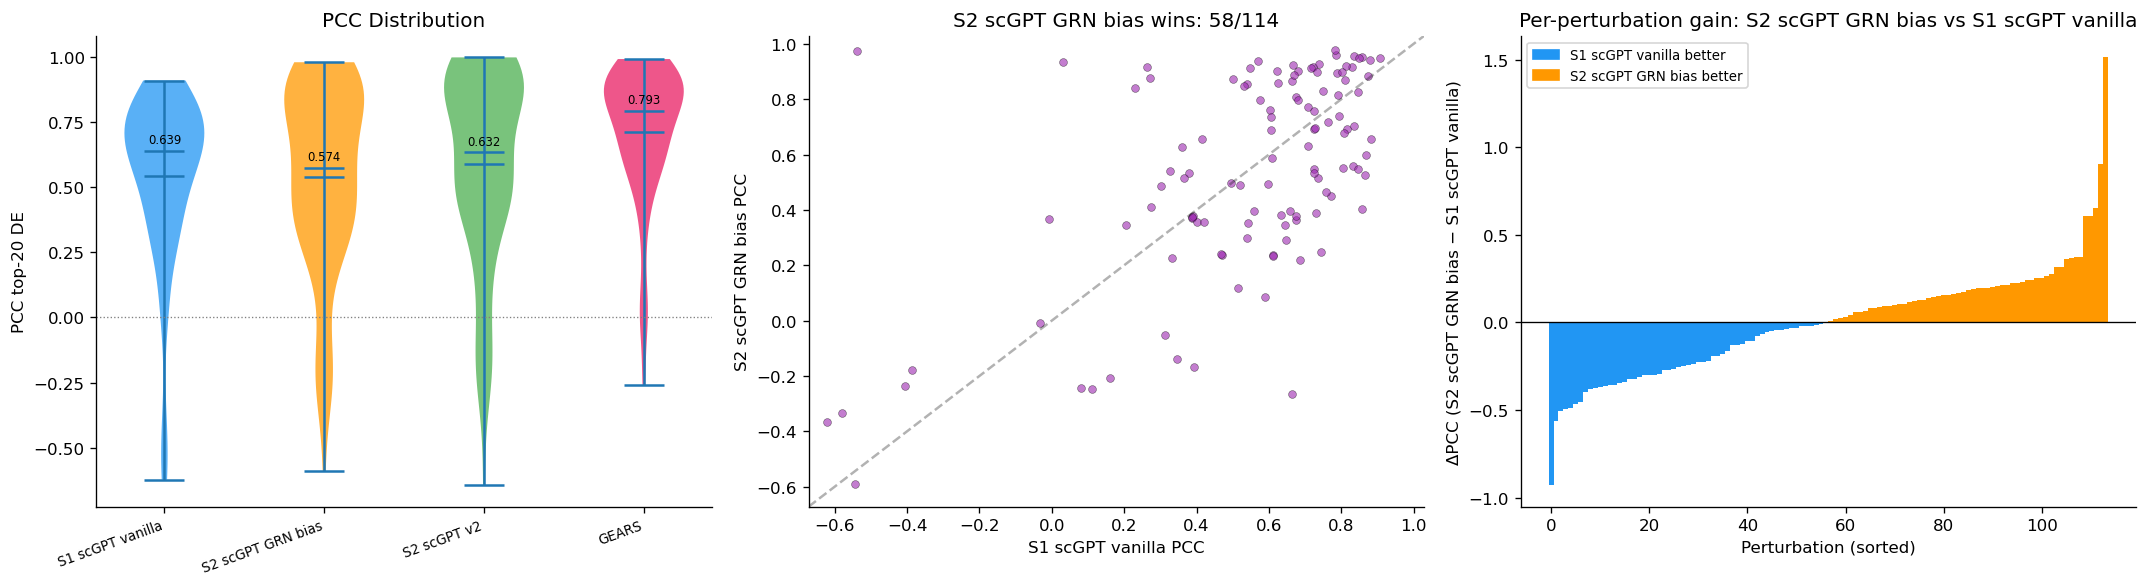

In [14]:
#5.1 PCC violin + pairwise scatter + delta bar (first two models)
if len(labels_ok) < 2:
    print('Need >= 2 models.')
else:
    shared = sorted(set.intersection(*[set(model_dfs[l]['perturbation']) for l in labels_ok]))
    pcc_vals = {l: model_dfs[l].set_index('perturbation').loc[shared, 'pcc_top20'].values
                for l in labels_ok}
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    parts = axes[0].violinplot([pcc_vals[l] for l in labels_ok], showmeans=True, showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors_map[labels_ok[i]]); pc.set_alpha(0.75)
    axes[0].set_xticks(range(1, len(labels_ok)+1))
    axes[0].set_xticklabels(labels_ok, rotation=20, ha='right', fontsize=8)
    axes[0].set_ylabel('PCC top-20 DE'); axes[0].set_title('PCC Distribution')
    axes[0].axhline(0, ls=':', c='gray', lw=0.8)
    for i, l in enumerate(labels_ok):
        med = np.median(pcc_vals[l])
        axes[0].text(i+1, med+0.03, f'{med:.3f}', ha='center', fontsize=7)
    sns.despine(ax=axes[0])
    l0, l1 = labels_ok[0], labels_ok[1]
    v0, v1 = pcc_vals[l0], pcc_vals[l1]
    axes[1].scatter(v0, v1, alpha=0.6, s=22, color='#9C27B0', edgecolors='k', lw=0.3)
    lim = [min(v0.min(), v1.min())-0.05, max(v0.max(), v1.max())+0.05]
    axes[1].plot(lim, lim, 'k--', alpha=0.3)
    axes[1].set_xlim(lim); axes[1].set_ylim(lim)
    axes[1].set_xlabel(f'{l0} PCC'); axes[1].set_ylabel(f'{l1} PCC')
    axes[1].set_title(f'{l1} wins: {(v1>v0).sum()}/{len(shared)}')
    sns.despine(ax=axes[1])
    delta = v1 - v0
    order = np.argsort(delta)
    bar_cols = [colors_map[l1] if d > 0 else colors_map[l0] for d in delta[order]]
    axes[2].bar(range(len(delta)), delta[order], color=bar_cols, width=1.0)
    axes[2].axhline(0, color='black', lw=0.8)
    axes[2].set_xlabel('Perturbation (sorted)'); axes[2].set_ylabel(f'ΔPCC ({l1} − {l0})')
    axes[2].set_title(f'Per-perturbation gain: {l1} vs {l0}')
    axes[2].legend(handles=[mpatches.Patch(color=colors_map[l0], label=f'{l0} better'),
                             mpatches.Patch(color=colors_map[l1], label=f'{l1} better')], fontsize=8)
    sns.despine(ax=axes[2])
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'pcc_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

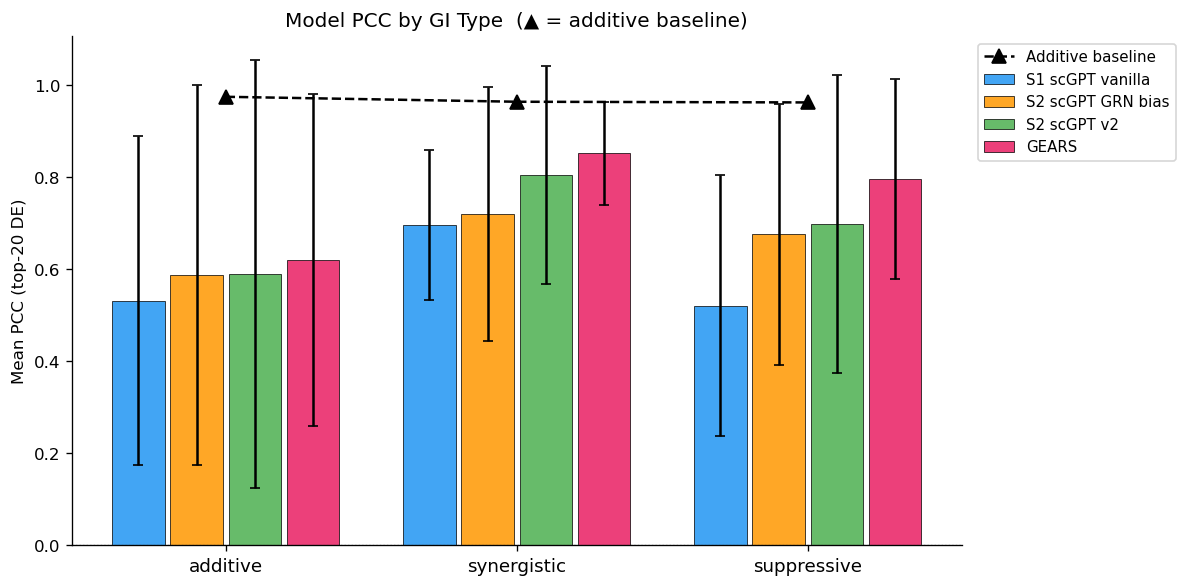

In [15]:
#5.2 Grouped bar: model PCC by GI type + additive baseline
gi_present = [t for t in GI_ORDER if any(t in model_dfs[l]['gi_type'].values for l in labels_ok)]
x = np.arange(len(gi_present)); w = 0.8 / len(labels_ok)
fig, ax = plt.subplots(figsize=(10, 5))
for i, label in enumerate(labels_ok):
    df = model_dfs[label]
    means = [df[df['gi_type'] == gt]['pcc_top20'].mean() for gt in gi_present]
    stds  = [df[df['gi_type'] == gt]['pcc_top20'].std()  for gt in gi_present]
    offset = (i - len(labels_ok)/2 + 0.5) * w
    ax.bar(x + offset, means, w*0.9, yerr=stds, capsize=3,
           label=label, color=colors_map[label], alpha=0.85, edgecolor='k', lw=0.5)
add_means = [gi_df[gi_df['gi_type'] == gt]['pcc_additive_top20'].mean()
             if gt in gi_df['gi_type'].values else np.nan for gt in gi_present]
ax.plot(x, add_means, 'k^--', markersize=8, lw=1.5, label='Additive baseline', zorder=5)
ax.set_xticks(x); ax.set_xticklabels(gi_present, fontsize=11)
ax.set_ylabel('Mean PCC (top-20 DE)'); ax.set_title('Model PCC by GI Type  (\u25b2 = additive baseline)')
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.axhline(0, color='gray', ls=':', lw=0.8); sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(OUT_DIR / 'gi_type_bar.png', dpi=150, bbox_inches='tight')
plt.show()

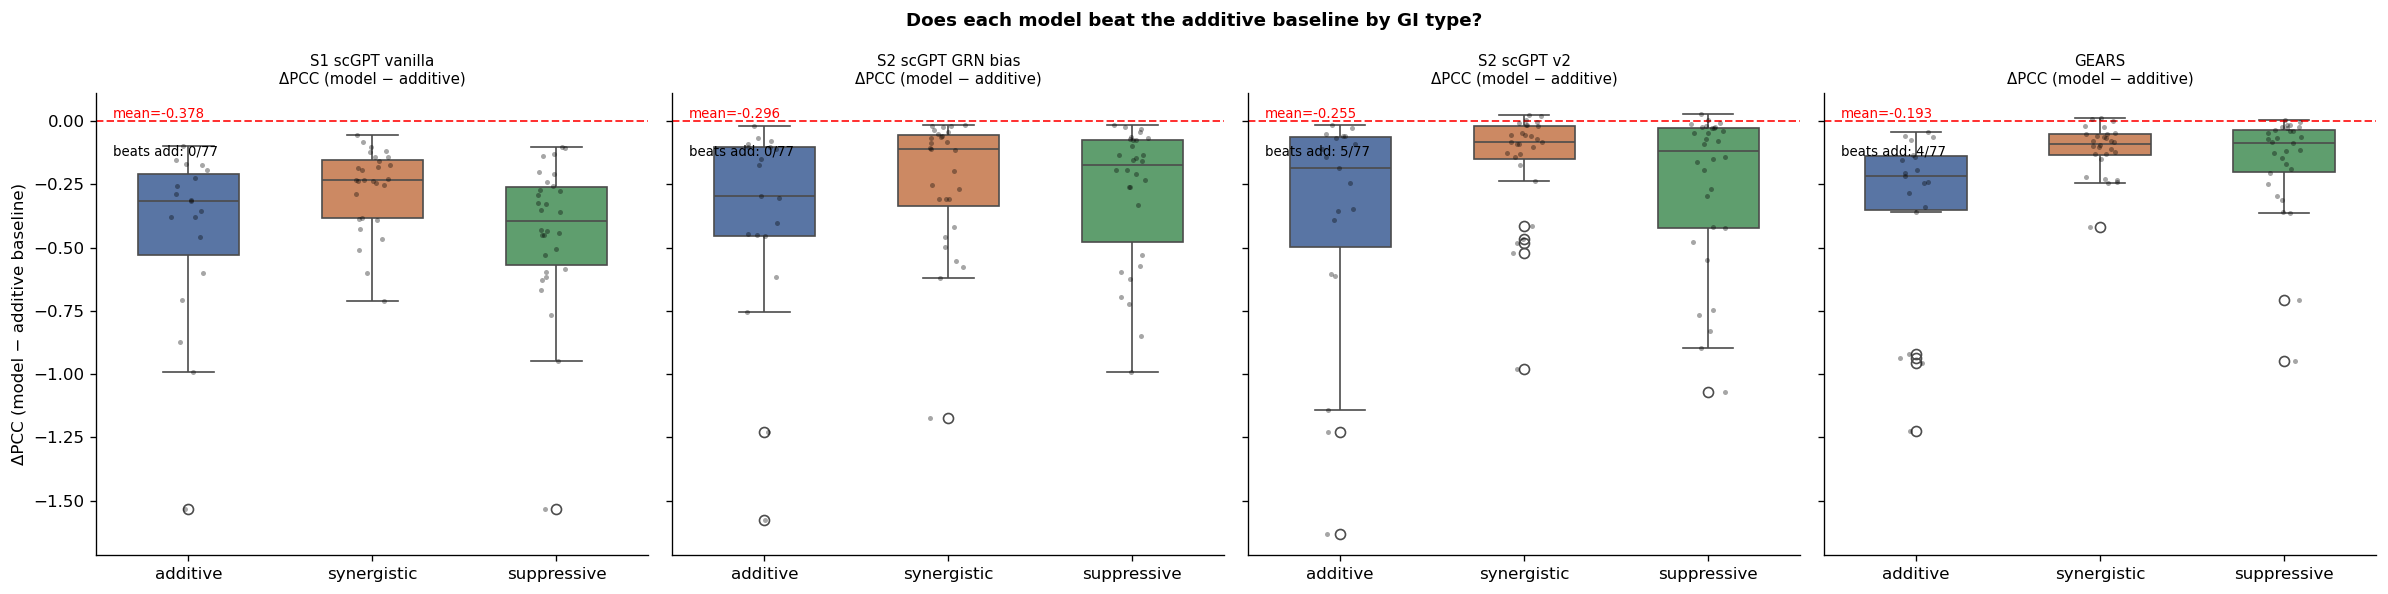

In [16]:
#5.3 ΔPCC (model − additive) by GI type
n_m = len(labels_ok)
fig, axes = plt.subplots(1, n_m, figsize=(5*n_m, 5), sharey=True)
if n_m == 1: axes = [axes]
for ax, label in zip(axes, labels_ok):
    df = model_dfs[label].copy()
    sub = df[df['gi_type'].isin(gi_present)].copy()
    sub['delta_pcc'] = sub['pcc_top20'] - sub['pcc_additive_top20']
    sns.boxplot(data=sub, x='gi_type', y='delta_pcc', order=gi_present, palette=palette, ax=ax, width=0.55)
    sns.stripplot(data=sub, x='gi_type', y='delta_pcc', order=gi_present,
                  color='black', alpha=0.35, size=3, jitter=True, ax=ax)
    ax.axhline(0, color='red', ls='--', lw=1.2, alpha=0.8)
    ax.set_title(f'{label}\n\u0394PCC (model \u2212 additive)', fontsize=9); ax.set_xlabel('')
    mean_d = sub['delta_pcc'].mean(); wins = (sub['delta_pcc'] > 0).sum()
    ax.text(0.03, 0.97, f'mean={mean_d:+.3f}', transform=ax.transAxes, fontsize=8, va='top', color='red')
    ax.text(0.03, 0.89, f'beats add: {wins}/{len(sub)}', transform=ax.transAxes, fontsize=8, va='top')
    sns.despine(ax=ax)
axes[0].set_ylabel('\u0394PCC (model \u2212 additive baseline)')
plt.suptitle('Does each model beat the additive baseline by GI type?', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'delta_pcc_by_gi.png', dpi=150, bbox_inches='tight')
plt.show()

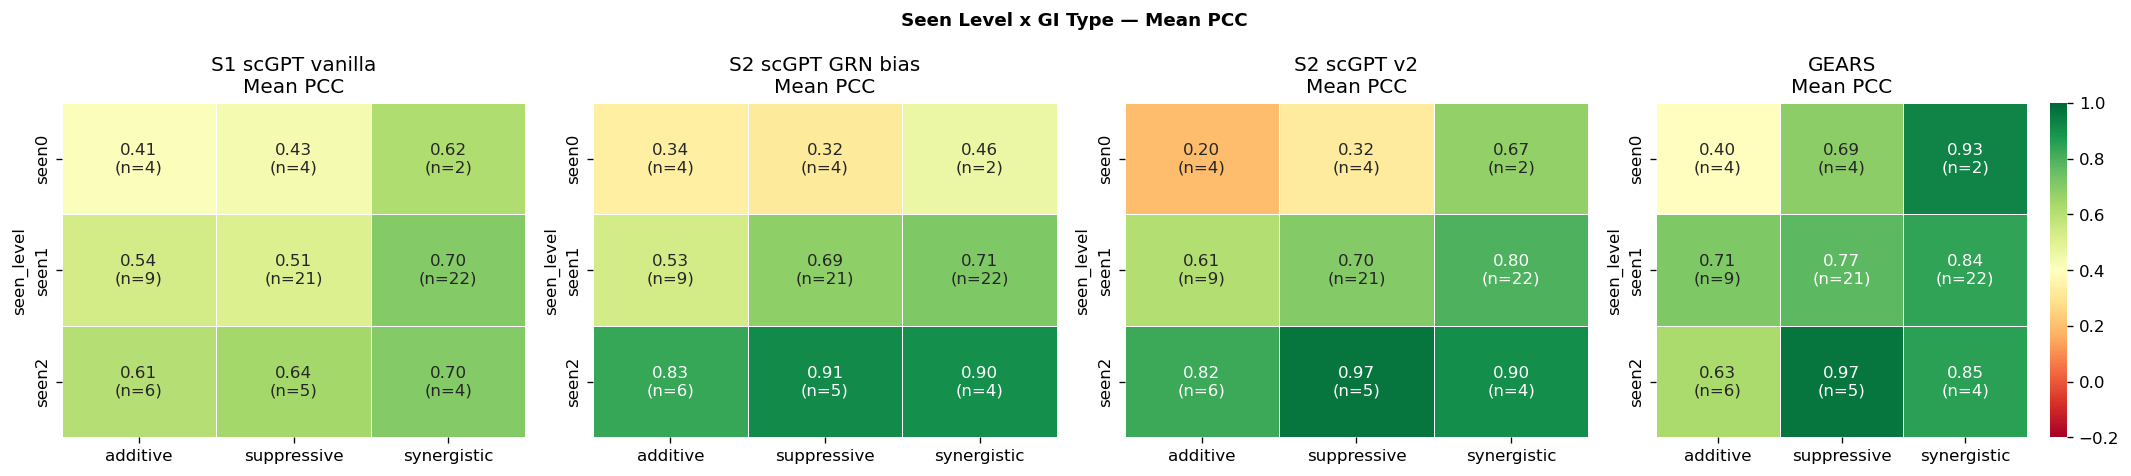

In [17]:
#5.4 Cross-tab heatmap: Seen Level x GI Type
n_m = len(labels_ok)
fig, axes = plt.subplots(1, n_m, figsize=(4.5*n_m, 4))
if n_m == 1: axes = [axes]
for ax, label in zip(axes, labels_ok):
    df = model_dfs[label]
    sub = df[df['gi_type'].isin(GI_ORDER)]
    pcc_tab = sub.pivot_table(values='pcc_top20', index='seen_level', columns='gi_type', aggfunc='mean')
    n_tab   = sub.pivot_table(values='perturbation', index='seen_level', columns='gi_type', aggfunc='count')
    annot = pcc_tab.copy().astype(object)
    for col in pcc_tab.columns:
        for idx in pcc_tab.index:
            try:
                v = pcc_tab.loc[idx, col]; n = int(n_tab.loc[idx, col]) if idx in n_tab.index and col in n_tab.columns else 0
                annot.loc[idx, col] = f'{v:.2f}\n(n={n})' if not np.isnan(v) else 'N/A'
            except Exception: annot.loc[idx, col] = 'N/A'
    sns.heatmap(pcc_tab, annot=annot, fmt='', cmap='RdYlGn', ax=ax,
                vmin=-0.2, vmax=1.0, linewidths=0.5, cbar=(ax == axes[-1]))
    ax.set_title(f'{label}\nMean PCC'); ax.set_xlabel('')
plt.suptitle('Seen Level x GI Type — Mean PCC', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'heatmap_seen_x_gi.png', dpi=150, bbox_inches='tight')
plt.show()

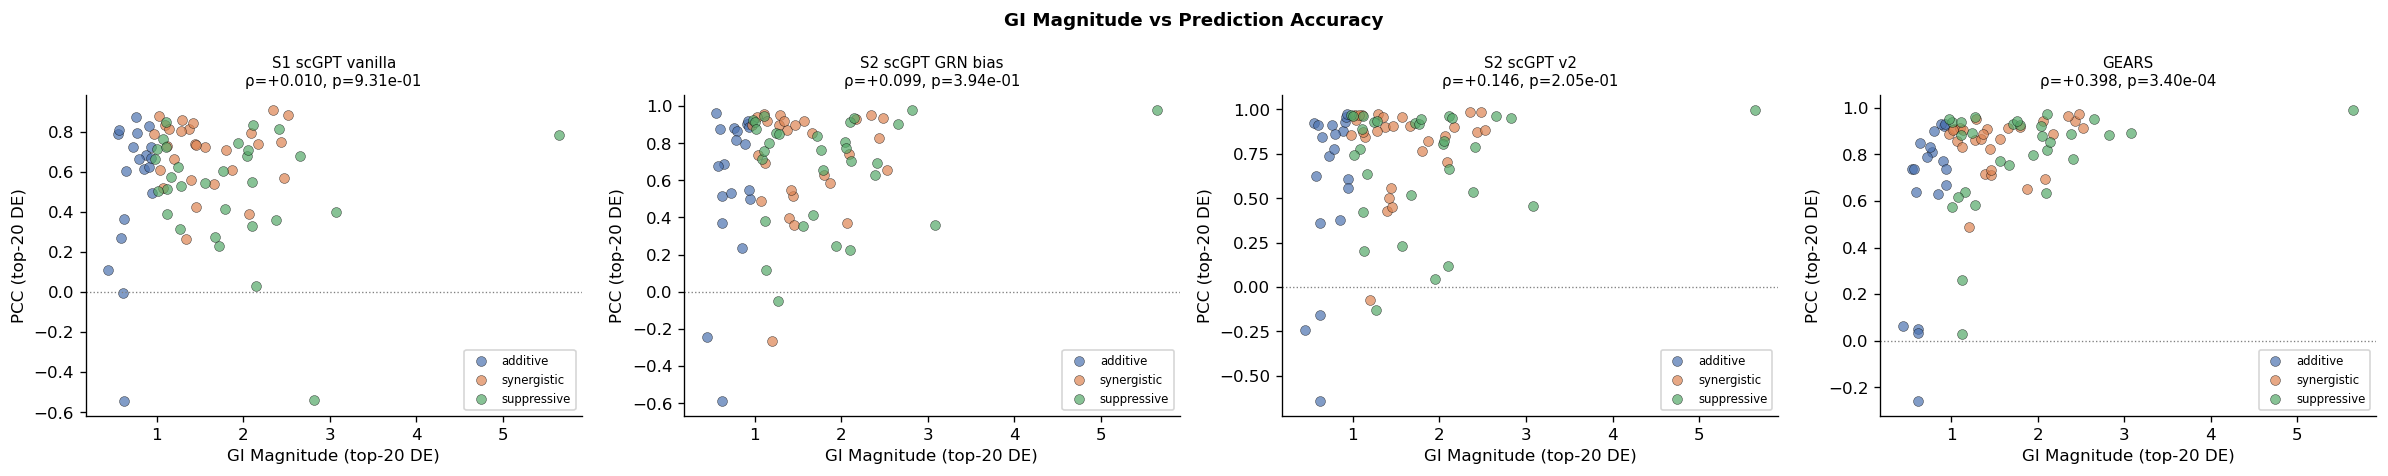

In [18]:
#5.5 GI magnitude vs PCC scatter
n_m = len(labels_ok)
fig, axes = plt.subplots(1, n_m, figsize=(5*n_m, 4), sharey=False)
if n_m == 1: axes = [axes]
for ax, label in zip(axes, labels_ok):
    df = model_dfs[label].dropna(subset=['gi_magnitude_top20'])
    rho, pval = spearmanr(df['gi_magnitude_top20'], df['pcc_top20'])
    for gt in gi_present:
        sub = df[df['gi_type'] == gt]
        ax.scatter(sub['gi_magnitude_top20'], sub['pcc_top20'],
                   c=palette[gt], label=gt, alpha=0.7, edgecolors='k', lw=0.3, s=35)
    ax.axhline(0, color='gray', ls=':', lw=0.8)
    ax.set_xlabel('GI Magnitude (top-20 DE)'); ax.set_ylabel('PCC (top-20 DE)')
    ax.set_title(f'{label}\n\u03c1={rho:+.3f}, p={pval:.2e}', fontsize=9)
    ax.legend(fontsize=7); sns.despine(ax=ax)
plt.suptitle('GI Magnitude vs Prediction Accuracy', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'gi_magnitude_vs_pcc.png', dpi=150, bbox_inches='tight')
plt.show()

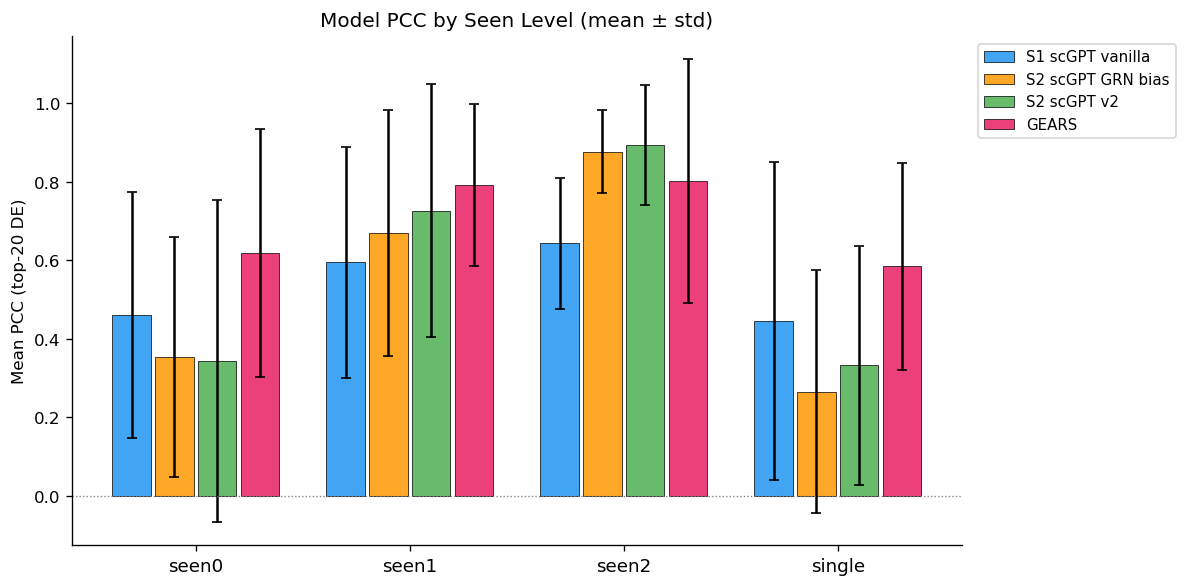

In [19]:
#5.6 Seen-level PCC bar chart
x = np.arange(len(SEEN_ORDER)); w = 0.8 / len(labels_ok)
fig, ax = plt.subplots(figsize=(10, 5))
for i, label in enumerate(labels_ok):
    df = model_dfs[label]
    means = [df[df['seen_level'] == lv]['pcc_top20'].mean() for lv in SEEN_ORDER]
    stds  = [df[df['seen_level'] == lv]['pcc_top20'].std()  for lv in SEEN_ORDER]
    offset = (i - len(labels_ok)/2 + 0.5) * w
    ax.bar(x + offset, means, w*0.9, yerr=stds, capsize=3,
           label=label, color=colors_map[label], alpha=0.85, edgecolor='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(SEEN_ORDER, fontsize=11)
ax.set_ylabel('Mean PCC (top-20 DE)'); ax.set_title('Model PCC by Seen Level (mean \u00b1 std)')
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.axhline(0, color='gray', ls=':', lw=0.8); sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(OUT_DIR / 'seen_level_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Statistical Tests

In [20]:
#6.1 Mann-Whitney: ΔPCC by GI type
print('Mann-Whitney U — ΔPCC by GI type (additive vs each other type)')
for label in labels_ok:
    df = model_dfs[label].copy()
    sub = df[df['gi_type'].isin(gi_present)].copy()
    sub['delta_pcc'] = sub['pcc_top20'] - sub['pcc_additive_top20']
    ref = sub.loc[sub['gi_type'] == 'additive', 'delta_pcc']
    print(f'\n  [{label}]')
    for gt in ['synergistic', 'suppressive', 'neomorphic']:
        other = sub.loc[sub['gi_type'] == gt, 'delta_pcc']
        if len(ref) < 3 or len(other) < 3:
            print(f'    additive vs {gt:<12}: insufficient data'); continue
        stat, pval = mannwhitneyu(ref, other, alternative='two-sided')
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        print(f'    additive vs {gt:<12}: U={stat:.0f}  p={pval:.4f}  {sig}')

Mann-Whitney U — ΔPCC by GI type (additive vs each other type)

  [S1 scGPT vanilla]
    additive vs synergistic : U=182  p=0.0703  ns
    additive vs suppressive : U=307  p=0.6591  ns
    additive vs neomorphic  : insufficient data

  [S2 scGPT GRN bias]
    additive vs synergistic : U=201  p=0.1620  ns
    additive vs suppressive : U=244  p=0.4059  ns
    additive vs neomorphic  : insufficient data

  [S2 scGPT v2]
    additive vs synergistic : U=169  p=0.0364  *
    additive vs suppressive : U=224  p=0.2144  ns
    additive vs neomorphic  : insufficient data

  [GEARS]
    additive vs synergistic : U=123  p=0.0020  **
    additive vs suppressive : U=157  p=0.0089  **
    additive vs neomorphic  : insufficient data


In [21]:
#6.2 Spearman: GI magnitude vs PCC / MSE
print('Spearman correlation — GI magnitude vs model performance')
print(f'{"Model":<28} {"rho(PCC)":>8} {"p(PCC)":>10} {"rho(MSE)":>8} {"p(MSE)":>10}')
print('-' * 68)
for label in labels_ok:
    df = model_dfs[label].dropna(subset=['gi_magnitude_top20', 'pcc_top20', 'mse_top20'])
    r_pcc, p_pcc = spearmanr(df['gi_magnitude_top20'], df['pcc_top20'])
    r_mse, p_mse = spearmanr(df['gi_magnitude_top20'], df['mse_top20'])
    print(f'{label:<28} {r_pcc:>+8.3f} {p_pcc:>10.3e} {r_mse:>+8.3f} {p_mse:>10.3e}')

Spearman correlation — GI magnitude vs model performance
Model                        rho(PCC)     p(PCC) rho(MSE)     p(MSE)
--------------------------------------------------------------------
S1 scGPT vanilla               +0.010  9.306e-01   +0.510  2.205e-06
S2 scGPT GRN bias              +0.099  3.939e-01   +0.453  3.460e-05
S2 scGPT v2                    +0.146  2.052e-01   +0.356  1.473e-03
GEARS                          +0.398  3.396e-04   +0.146  2.041e-01


In [22]:
#6.3 Top improved / regressed cases (first two models)
if len(labels_ok) >= 2:
    l0, l1 = labels_ok[0], labels_ok[1]
    shared = sorted(set.intersection(*[set(model_dfs[l]['perturbation']) for l in labels_ok]))
    df_cmp = pd.DataFrame({
        'perturbation': shared,
        l0: model_dfs[l0].set_index('perturbation').loc[shared, 'pcc_top20'].values,
        l1: model_dfs[l1].set_index('perturbation').loc[shared, 'pcc_top20'].values,
    })
    df_cmp['gi_type'] = [model_dfs[l0].set_index('perturbation').loc[p, 'gi_type'] for p in shared]
    df_cmp['delta'] = df_cmp[l1] - df_cmp[l0]
    print(f'Top 10 where {l1} improved most vs {l0}:')
    print(df_cmp.nlargest(10, 'delta')[['perturbation', 'gi_type', l0, l1, 'delta']].round(4).to_string(index=False))
    print(f'\nTop 10 where {l1} regressed most vs {l0}:')
    print(df_cmp.nsmallest(10, 'delta')[['perturbation', 'gi_type', l0, l1, 'delta']].round(4).to_string(index=False))

Top 10 where S2 scGPT GRN bias improved most vs S1 scGPT vanilla:
perturbation     gi_type  S1 scGPT vanilla  S2 scGPT GRN bias  delta
 CEBPB+MAPK1 suppressive           -0.5375             0.9759 1.5133
  ETS2+MAPK1 suppressive            0.0306             0.9351 0.9045
ZBTB10+SNAI1 synergistic            0.2643             0.9181 0.6538
  ETS2+CEBPE suppressive            0.2290             0.8391 0.6100
 TGFBR2+ETS2    additive            0.2711             0.8766 0.6055
 TMSB4X+BAK1    additive           -0.0070             0.3678 0.3749
UBASH3B+OSR2 suppressive            0.5016             0.8749 0.3733
UBASH3B+CNN1 synergistic            0.5688             0.9368 0.3680
  DUSP9+PRTG suppressive            0.5479             0.9123 0.3645
MAP2K3+IKZF3 suppressive            0.5311             0.8489 0.3178

Top 10 where S2 scGPT GRN bias regressed most vs S1 scGPT vanilla:
 perturbation     gi_type  S1 scGPT vanilla  S2 scGPT GRN bias   delta
  FOSB+PTPN12 synergistic           

## 7. Export

In [23]:
#7.1 Save annotated CSVs per model + combined
for label in labels_ok:
    safe = label.replace(' ', '_').replace('/', '_')
    model_dfs[label].to_csv(OUT_DIR / f'eval_{safe}.csv', index=False)
    print(f'Saved: eval_{safe}.csv')

if len(labels_ok) >= 2:
    shared = sorted(set.intersection(*[set(model_dfs[l]['perturbation']) for l in labels_ok]))
    anchor = model_dfs[labels_ok[0]][['perturbation', 'seen_level', 'gi_type',
                                      'gi_magnitude_top20', 'pcc_additive_top20']].copy()
    anchor = anchor[anchor['perturbation'].isin(shared)]
    for label in labels_ok:
        safe = label.replace(' ', '_')
        tmp = model_dfs[label][['perturbation', 'pcc_top20', 'mse_top20']].rename(
            columns={'pcc_top20': f'pcc_{safe}', 'mse_top20': f'mse_{safe}'})
        anchor = anchor.merge(tmp, on='perturbation', how='inner')
    anchor.to_csv(OUT_DIR / 'eval_combined.csv', index=False)
    print(f'Combined ({len(anchor)} shared): eval_combined.csv')

gi_df.to_csv(OUT_DIR / 'gi_annotations.csv', index=False)
print(f'All outputs in: {OUT_DIR.resolve()}')

Saved: eval_S1_scGPT_vanilla.csv
Saved: eval_S2_scGPT_GRN_bias.csv
Saved: eval_S2_scGPT_v2.csv
Saved: eval_GEARS.csv
Combined (114 shared): eval_combined.csv
All outputs in: /scratch/users/astar/imcb/hudh/PerturbT/notebooks/Evaluation/output


## 8. Per-Perturbation Top-20 Gene Visualization

Loads ALL configured models — scGPT (vanilla/GRN-biased) and GEARS — into a unified bundle interface.  
For each perturbation:
- **Left**: top-20 DE genes: actual delta (boxplot) + each model (dots) + additive baseline (line)
- **Right**: all-gene scatter: predicted vs actual delta, top-20 highlighted in red

Visualization gene space: scGPT HVG (1251 genes).  
GEARS full predictions (5045 genes) are subset to HVG genes by name; missing genes set to delta=0.

In [24]:
#8.1 Build HVG-subset adata (leak-fixed, identical to scGPT training)
train_adata = adata[adata.obs['split'] == 'train'].copy()
train_perturbed_genes = set()
for cond in train_adata.obs['condition'].unique():
    if cond != 'ctrl':
        for p in cond.split('+'):
            if p != 'ctrl': train_perturbed_genes.add(p)

sc.pp.highly_variable_genes(train_adata, n_top_genes=1200, flavor='seurat', subset=False)
hvg_genes = set(train_adata.var[train_adata.var['highly_variable']].index)
hvg_genes.update(train_perturbed_genes & set(adata.var_names))
adata_hvg = adata[:, adata.var_names.isin(hvg_genes)].copy()

ctrl_hvg = adata_hvg[(adata_hvg.obs['condition'] == 'ctrl') & (adata_hvg.obs['split'] == 'train')]
ctrl_X_pool = ctrl_hvg.X.toarray() if sparse.issparse(ctrl_hvg.X) else ctrl_hvg.X

all_ctrl_hvg = adata_hvg[adata_hvg.obs['condition'] == 'ctrl']
ctrl_mean_hvg = (all_ctrl_hvg.X.toarray() if sparse.issparse(all_ctrl_hvg.X)
                 else all_ctrl_hvg.X).mean(axis=0)

genes_hvg    = adata_hvg.var_names.tolist()
n_genes_hvg  = len(genes_hvg)
gene2idx_hvg = {g: i for i, g in enumerate(genes_hvg)}

print(f'HVG adata: {adata_hvg.shape}, control pool: {ctrl_X_pool.shape[0]} cells')

HVG adata: (89357, 1251), control pool: 7353 cells


In [25]:
#8.2 scGPT vocab + gene IDs
from scgpt.tokenizer import GeneVocab
from scgpt.utils import map_raw_id_to_vocab_id
from scgpt.model import TransformerGenerator

vocab_file = Path(MODEL_DIR) / 'vocab.json'
vocab = GeneVocab.from_file(vocab_file)
for s in SPECIAL_TOKENS:
    if s not in vocab: vocab.append_token(s)

gene_ids_hvg = np.array(
    [vocab[g] if g in vocab else vocab[PAD_TOKEN] for g in genes_hvg], dtype=int)
ntokens = len(vocab)
print(f'Vocab match: {sum(1 for g in genes_hvg if g in vocab)}/{n_genes_hvg} HVGs')

Vocab match: 1146/1251 HVGs


In [26]:
#8.3 GRNAttentionBias class (required for GRN-biased scGPT models)
class GRNAttentionBias(nn.Module):
    def __init__(self, original_attn, M_grn, alpha):
        super().__init__()
        self.original_attn = original_attn
        self.M_grn  = M_grn
        self.alpha  = alpha
        self._current_gene_indices = None

    def __getattr__(self, name):
        try:
            return super().__getattr__(name)
        except AttributeError:
            orig = self.__dict__.get('_modules', {}).get('original_attn')
            if orig is not None: return getattr(orig, name)
            raise

    def forward(self, query, key, value, key_padding_mask=None,
                need_weights=False, attn_mask=None, **kwargs):
        idx = self._current_gene_indices
        grn_bias = self.alpha * (self.M_grn[idx][:, idx] if idx is not None
                                 else self.M_grn[:query.size(0), :query.size(0)])
        attn_mask = grn_bias if attn_mask is None else attn_mask + grn_bias
        return self.original_attn(query, key, value,
                                  key_padding_mask=key_padding_mask,
                                  need_weights=need_weights,
                                  attn_mask=attn_mask, **kwargs)

In [27]:
#8.4 Model loaders
def load_scgpt_bundle(cfg):
    save_dir = Path(cfg['save_dir'])
    M_path   = save_dir / 'M_aligned.npy'
    is_grn   = M_path.exists()
    base = TransformerGenerator(
        ntokens, EMBSIZE, NHEAD, D_HID, NLAYERS,
        nlayers_cls=N_LAYERS_CLS, n_cls=1, vocab=vocab, dropout=DROPOUT,
        pad_token=PAD_TOKEN, pad_value=0, pert_pad_id=0,
        use_fast_transformer=False,
    )
    patched_attns = []
    if is_grn:
        M = torch.tensor(np.load(M_path).astype(np.float32), dtype=torch.float32, device=device)
        alpha = nn.Parameter(torch.tensor(0.1))
        for layer in base.transformer_encoder.layers:
            w = GRNAttentionBias(layer.self_attn, M, alpha)
            layer.self_attn = w
            patched_attns.append(w)
        base.alpha_grn = alpha
    state = torch.load(save_dir / 'best_model.pt', map_location=device)
    base.load_state_dict(state, strict=False)
    base.to(device).eval()
    tag = f'GRN alpha={base.alpha_grn.item():.4f}' if is_grn else 'vanilla'
    print(f'  [{cfg["label"]}] scGPT {tag}')
    return {'label': cfg['label'], 'color': cfg['color'], 'type': 'scgpt',
            'model': base, 'patched_attns': patched_attns, 'save_dir': save_dir}


def load_gears_bundle(cfg):
    from gears import PertData, GEARS as GEARSModel
    save_dir = Path(cfg['save_dir'])
    pd_obj = PertData(cfg['gears_data_dir'])
    pd_obj.load(data_name=cfg['gears_data_name'])
    pd_obj.prepare_split(split='simulation', seed=cfg['gears_split_seed'])
    pd_obj.get_dataloader(batch_size=256, test_batch_size=512)
    gm = GEARSModel(pd_obj, device=str(device), weight_bias_track=False,
                    proj_name='gears_eval', exp_name='gears_eval')
    gm.model_initialize(hidden_size=64)
    gm.load_pretrained(str(save_dir / 'gears_model'))
    gene_names = list(pd_obj.gene_names)
    gene2idx_gears = {g: i for i, g in enumerate(gene_names)}
    print(f'  [{cfg["label"]}] GEARS loaded, {len(gene_names)} genes')
    return {'label': cfg['label'], 'color': cfg['color'], 'type': 'gears',
            'model': gm, 'gene_names': gene_names, 'gene2idx': gene2idx_gears,
            'save_dir': save_dir}


bundles = []
for cfg in MODEL_CONFIGS:
    try:
        if cfg['type'] == 'scgpt':
            bundles.append(load_scgpt_bundle(cfg))
        elif cfg['type'] == 'gears':
            bundles.append(load_gears_bundle(cfg))
    except Exception as e:
        print(f'  SKIP [{cfg["label"]}]: {e}')

print(f'Loaded {len(bundles)} bundles: {[b["label"] for b in bundles]}')

  [S1 scGPT vanilla] scGPT vanilla
  [S2 scGPT GRN bias] scGPT GRN alpha=0.0993
  [S2 scGPT v2] scGPT GRN alpha=14.1231


Found local copy...
Local copy of pyg dataset is detected. Loading...
Done!
Local copy of split is detected. Loading...
Simulation split test composition:
combo_seen0:5
combo_seen1:55
combo_seen2:17
unseen_single:37
Done!
Creating dataloaders....
Done!


  SKIP [GEARS]: 'Series' object has no attribute 'nonzero'
Loaded 3 bundles: ['S1 scGPT vanilla', 'S2 scGPT GRN bias', 'S2 scGPT v2']


In [28]:
#8.5 Unified predict + helpers
def predict_bundle(bundle, pert):
    """
    Returns predicted delta expression in HVG space (n_genes_hvg,).
    scGPT: direct inference in HVG space.
    GEARS: infer in full gene space, map to HVG by gene name (missing -> delta 0).
    """
    if bundle['type'] == 'scgpt':
        model = bundle['model']
        model.eval()
        pool = min(POOL_SIZE, ctrl_X_pool.shape[0])
        idx_pool  = np.random.choice(ctrl_X_pool.shape[0], pool, replace=False)
        base_expr = torch.tensor(ctrl_X_pool[idx_pool], dtype=torch.float32)
        pert_flags = torch.zeros(n_genes_hvg, dtype=torch.long)
        for p in pert.split('+'):
            if p != 'ctrl' and p in gene2idx_hvg:
                pert_flags[gene2idx_hvg[p]] = 1
        input_gene_ids = torch.arange(n_genes_hvg, device=device, dtype=torch.long)
        mapped_ids = map_raw_id_to_vocab_id(input_gene_ids, gene_ids_hvg).to(device)
        mapped_ids = mapped_ids.repeat(pool, 1)
        for attn in bundle.get('patched_attns', []):
            attn._current_gene_indices = input_gene_ids
        input_pert = pert_flags.unsqueeze(0).repeat(pool, 1).to(device)
        src_mask   = torch.zeros_like(base_expr, dtype=torch.bool).to(device)
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=AMP):
            out = model(mapped_ids, base_expr.to(device), input_pert,
                        src_key_padding_mask=src_mask,
                        CLS=False, CCE=False, MVC=False, ECS=False)
        return out['mlm_output'].cpu().numpy().mean(axis=0) - ctrl_mean_hvg

    elif bundle['type'] == 'gears':
        gene_list = [p for p in pert.split('+') if p != 'ctrl']
        result    = bundle['model'].predict([gene_list])
        pred_full = list(result.values())[0]        # (n_gears_genes,)
        g2i = bundle['gene2idx']
        # Map to HVG space; genes not in GEARS -> use ctrl (delta = 0)
        pred_hvg = np.array([
            pred_full[g2i[g]] if g in g2i else ctrl_mean_hvg[i]
            for i, g in enumerate(genes_hvg)
        ])
        return pred_hvg - ctrl_mean_hvg


def additive_delta_hvg(pert):
    delta = np.zeros(n_genes_hvg)
    for p in pert.split('+'):
        if p == 'ctrl': continue
        for cand in [f'{p}+ctrl', f'ctrl+{p}', p]:
            mask = adata_hvg.obs['condition'] == cand
            if mask.sum() > 0:
                X = adata_hvg[mask].X
                if sparse.issparse(X): X = X.toarray()
                delta += X.mean(axis=0) - ctrl_mean_hvg
                break
    return delta


def actual_delta_cells_hvg(pert):
    mask = adata_hvg.obs['condition'] == pert
    X = adata_hvg[mask].X
    if sparse.issparse(X): X = X.toarray()
    return X - ctrl_mean_hvg      # (n_cells, n_genes_hvg)


print('Helpers ready.')

Helpers ready.


In [29]:
#8.6 Select perturbations to visualize
all_results = {}
for b in bundles:
    csv = b['save_dir'] / 'per_perturbation_results.csv'
    if csv.exists():
        df = pd.read_csv(csv)
        all_results[b['label']] = df.set_index('perturbation')

test_conds = set(adata_hvg[adata_hvg.obs['split'] == 'test'].obs['condition'].unique())
test_conds.discard('ctrl')

if SHOW_PERTS:
    perts_to_plot = [p for p in SHOW_PERTS if p in test_conds]
    missing = [p for p in SHOW_PERTS if p not in test_conds]
    if missing: print(f'WARNING: not in test set: {missing}')
else:
    combo_conds = [c for c in test_conds if '+' in c and 'ctrl' not in c]
    lbls = [b['label'] for b in bundles if b['label'] in all_results]
    if len(lbls) >= 2:
        shared_auto = list(set(all_results[lbls[0]].index) &
                           set(all_results[lbls[1]].index) & set(combo_conds))
        var_s = pd.DataFrame({l: all_results[l].loc[shared_auto, 'pcc_top20']
                               for l in lbls}).var(axis=1)
        perts_to_plot = var_s.nlargest(5).index.tolist()
    else:
        perts_to_plot = combo_conds[:5]

print(f'Perturbations to plot: {perts_to_plot}')

Perturbations to plot: ['CEBPB+MAPK1', 'ETS2+MAPK1', 'BCL2L11+TGFBR2', 'DUSP9+KLF1', 'CEBPE+SPI1']


In [30]:
#8.7 Plot function: top-20 bar + all-gene scatter
def plot_top20_case(pert, bundles, ax_bar, ax_scatter):
    cells      = actual_delta_cells_hvg(pert)   # (n_cells, n_genes)
    actual_mean = cells.mean(axis=0)
    top20_idx  = np.argsort(np.abs(actual_mean))[-20:]
    top20_genes = [genes_hvg[i] for i in top20_idx]
    add_delta  = additive_delta_hvg(pert)

    model_deltas = {b['label']: predict_bundle(b, pert) for b in bundles}

    # ---- BAR ----
    x = np.arange(len(top20_idx))
    ax_bar.boxplot(
        cells[:, top20_idx],
        positions=x, widths=0.45, showfliers=False, patch_artist=True,
        boxprops=dict(facecolor='#E0E0E0', alpha=0.8),
        medianprops=dict(color='black', lw=1.5),
        whiskerprops=dict(alpha=0.5), capprops=dict(alpha=0.5),
    )
    ax_bar.plot(x, add_delta[top20_idx], 'D--', color='gray',
                markersize=5, lw=1, alpha=0.8, label='Additive baseline', zorder=3)
    offsets = np.linspace(-0.18, 0.18, len(bundles))
    for i, b in enumerate(bundles):
        delta   = model_deltas[b['label']]
        pcc_ann = ''
        if b['label'] in all_results and pert in all_results[b['label']].index:
            pcc_ann = f" PCC={all_results[b['label']].loc[pert, 'pcc_top20']:.2f}"
        ax_bar.scatter(x + offsets[i], delta[top20_idx],
                       color=b['color'], s=40, zorder=4,
                       label=b['label'] + pcc_ann, edgecolors='k', linewidths=0.3)
    ax_bar.axhline(0, color='black', lw=0.8, ls=':')
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(top20_genes, rotation=60, ha='right', fontsize=7)
    ax_bar.set_ylabel('\u0394 expression (log-norm)')
    ax_bar.set_title(f'{pert} \u2014 top-20 DE genes', fontweight='bold')
    ax_bar.legend(fontsize=7, loc='upper left')
    sns.despine(ax=ax_bar)

    # ---- SCATTER ----
    for b in bundles:
        delta = model_deltas[b['label']]
        r, _  = pearsonr(delta, actual_mean)
        ax_scatter.scatter(actual_mean, delta, color=b['color'],
                           alpha=0.4, s=10, label=f"{b['label']} r={r:.2f}")
    r_add, _ = pearsonr(add_delta, actual_mean)
    ax_scatter.scatter(actual_mean, add_delta, color='gray',
                       alpha=0.3, s=8, label=f'Additive r={r_add:.2f}')
    # Top-20 highlighted for first model
    first_d = model_deltas[bundles[0]['label']]
    ax_scatter.scatter(actual_mean[top20_idx], first_d[top20_idx],
                       color='red', s=28, zorder=5, alpha=0.8,
                       label='top-20 (model 1)', edgecolors='k', lw=0.4)
    lim = max(np.abs(actual_mean).max(), 0.5) * 1.15
    ax_scatter.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.3, lw=0.8)
    ax_scatter.set_xlim(-lim, lim)
    ax_scatter.set_xlabel('Actual \u0394 expression')
    ax_scatter.set_ylabel('Predicted \u0394 expression')
    ax_scatter.set_title('All HVG genes: predicted vs actual', fontweight='bold')
    ax_scatter.legend(fontsize=7)
    sns.despine(ax=ax_scatter)

--- CEBPB+MAPK1  GI=suppressive  seen=seen1 ---


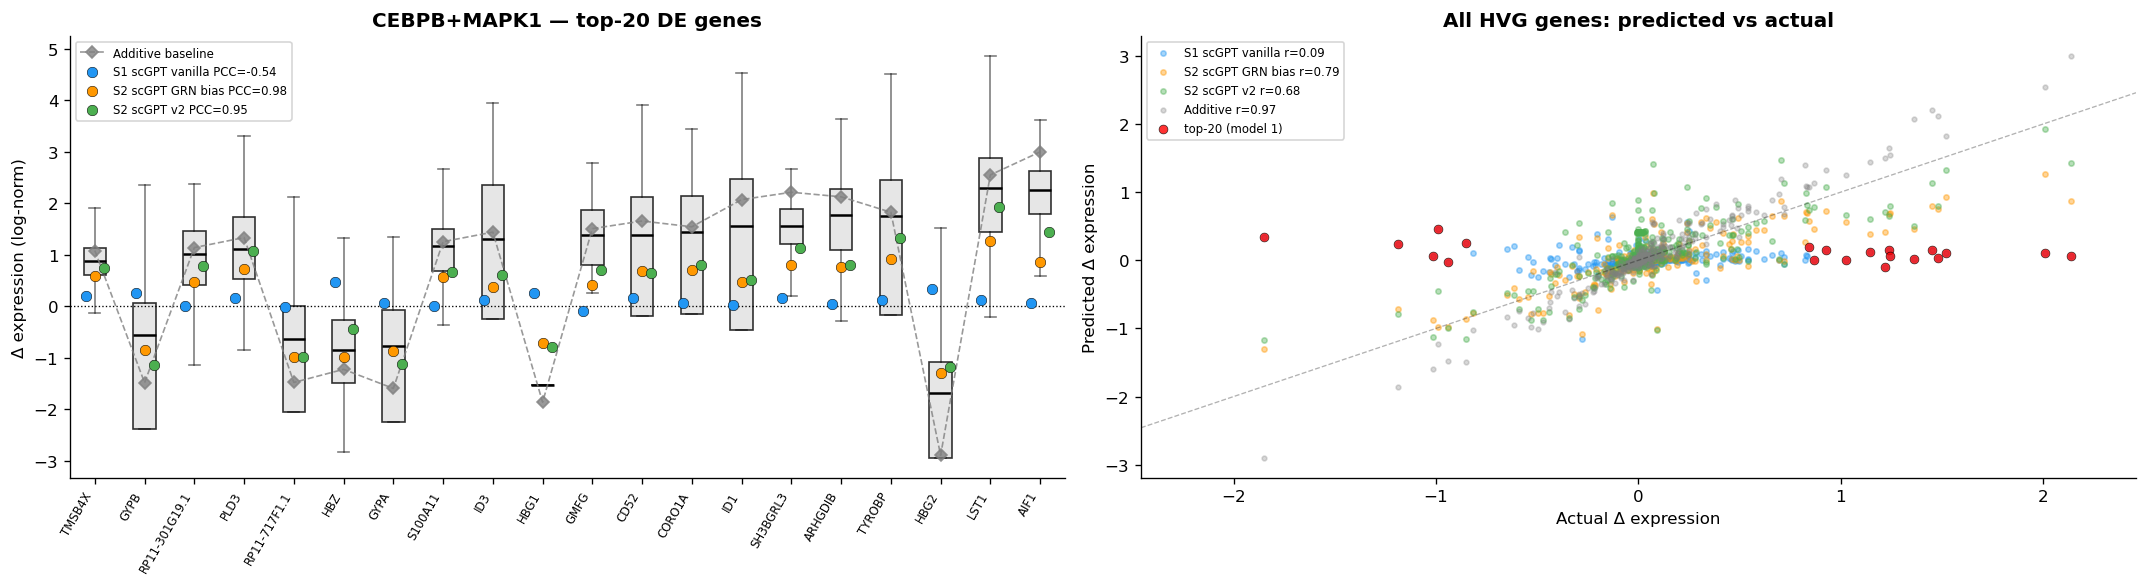


--- ETS2+MAPK1  GI=suppressive  seen=seen1 ---


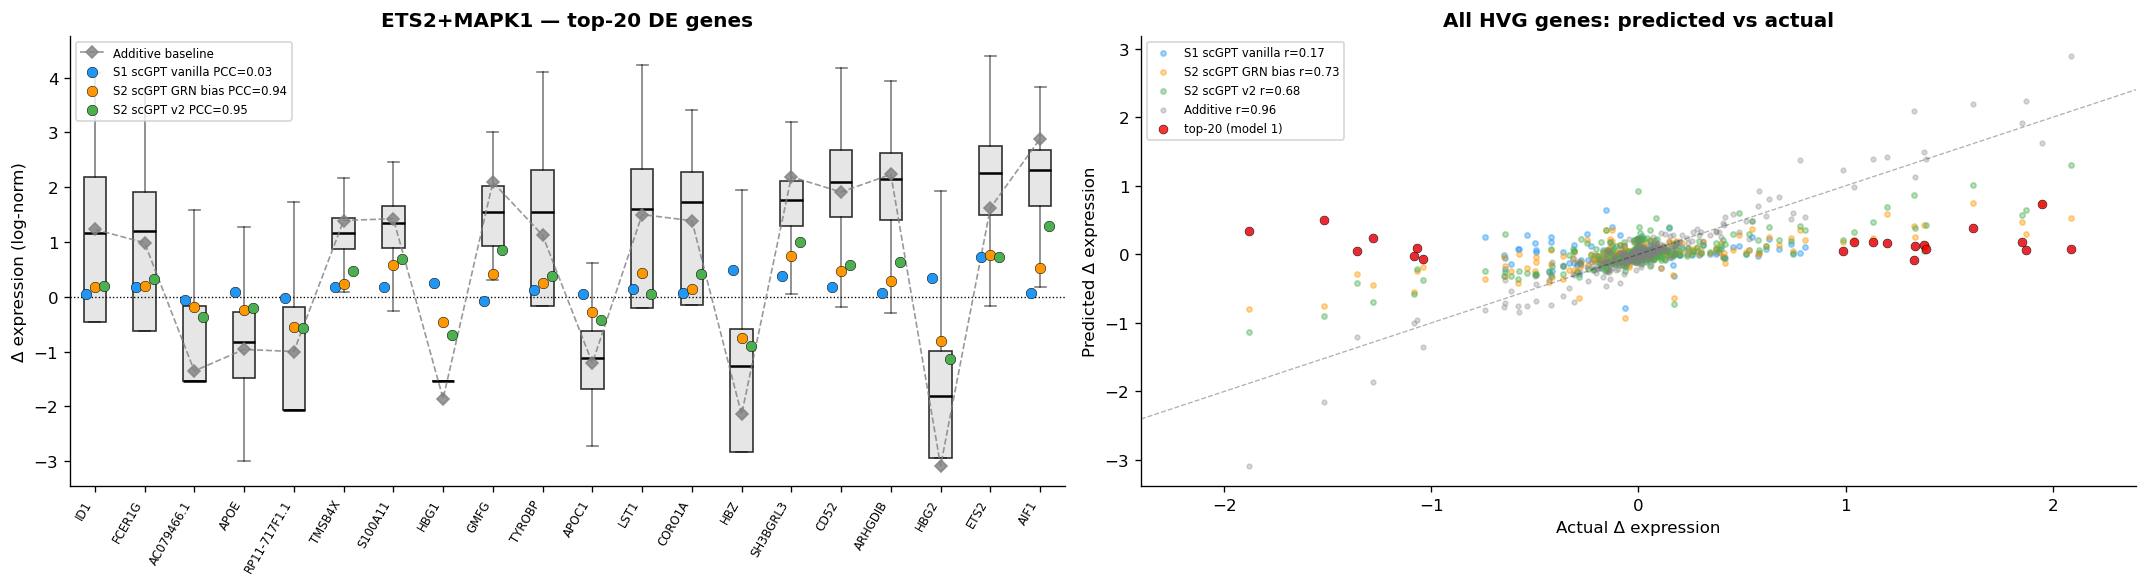


--- BCL2L11+TGFBR2  GI=additive  seen=seen2 ---


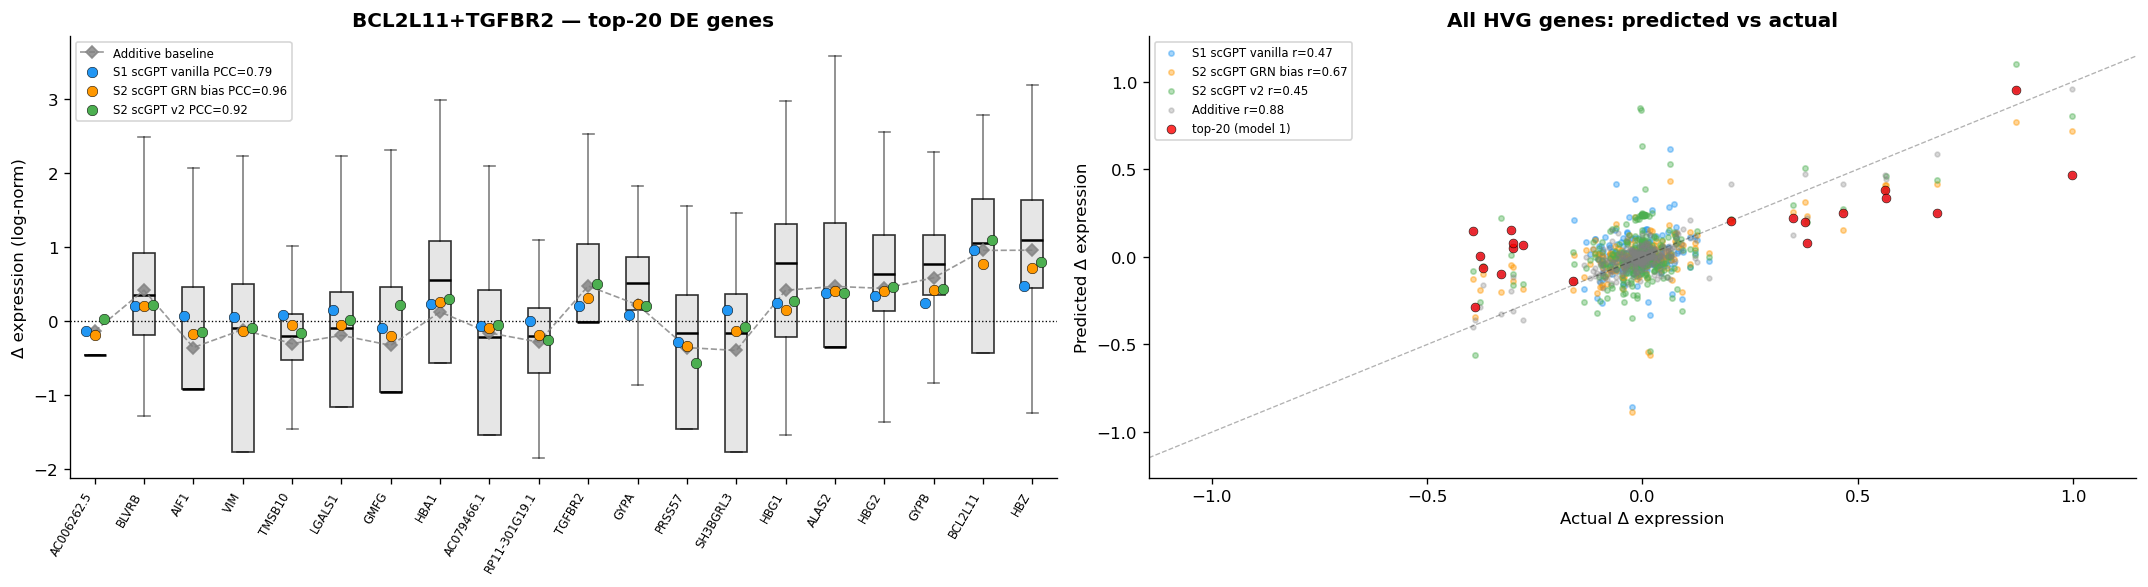


--- DUSP9+KLF1  GI=synergistic  seen=seen2 ---


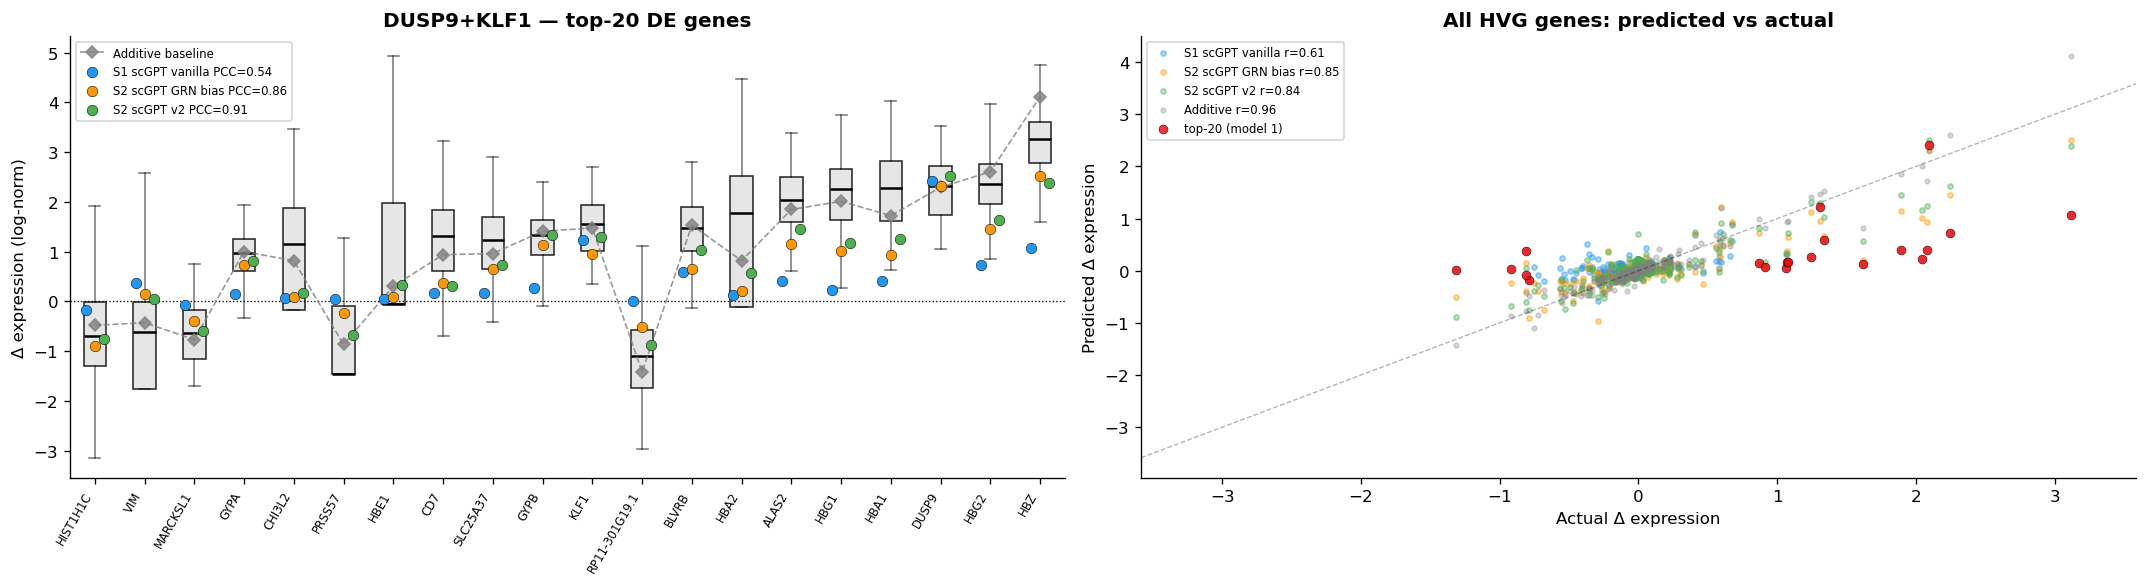


--- CEBPE+SPI1  GI=synergistic  seen=seen0 ---


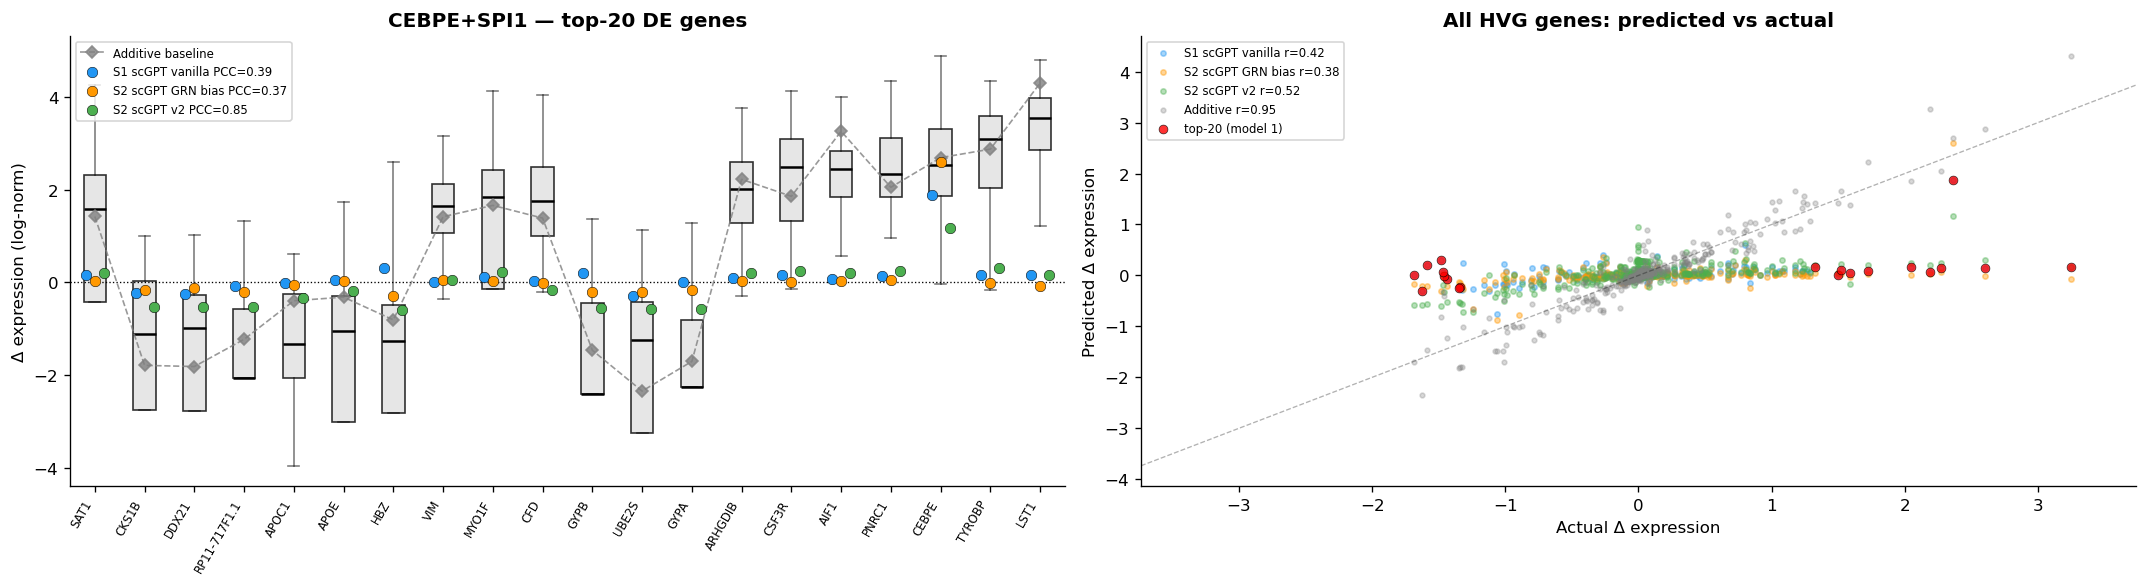

In [31]:
#8.8 Generate plots
np.random.seed(42)

for pert in perts_to_plot:
    gi_ann  = gi_lookup.get(pert, {})
    gi_str  = (gi_ann.get('gi_type', 'N/A') if isinstance(gi_ann, dict)
               else getattr(gi_ann, 'gi_type', 'N/A'))
    print(f'--- {pert}  GI={gi_str}  seen={get_seen_level(pert)} ---')
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    plot_top20_case(pert, bundles, axes[0], axes[1])
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'top20_{pert.replace("+", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print()

In [32]:
#8.9 Summary table: PCC across selected perturbations x all models
rows = []
for pert in perts_to_plot:
    gi_ann = gi_lookup.get(pert, {})
    gi_str = (gi_ann.get('gi_type', 'N/A') if isinstance(gi_ann, dict)
              else getattr(gi_ann, 'gi_type', 'N/A'))
    row = {'perturbation': pert, 'gi_type': gi_str, 'seen_level': get_seen_level(pert)}
    row['PCC_additive'] = (gi_lookup[pert].get('pcc_additive_top20', np.nan)
                           if pert in gi_lookup else np.nan)
    for b in bundles:
        row[f'PCC_{b["label"]}'] = (
            all_results[b['label']].loc[pert, 'pcc_top20']
            if b['label'] in all_results and pert in all_results[b['label']].index
            else np.nan)
    rows.append(row)

summary_df = pd.DataFrame(rows)
print('PCC (top-20 DE) for selected perturbations:')
print(summary_df.round(3).to_string(index=False))
summary_df.to_csv(OUT_DIR / 'top20_viz_summary.csv', index=False)
print(f'Saved: {OUT_DIR}/top20_viz_summary.csv')

PCC (top-20 DE) for selected perturbations:
  perturbation     gi_type seen_level  PCC_additive  PCC_S1 scGPT vanilla  PCC_S2 scGPT GRN bias  PCC_S2 scGPT v2
   CEBPB+MAPK1 suppressive      seen1         0.997                -0.537                  0.976            0.950
    ETS2+MAPK1 suppressive      seen1         0.978                 0.031                  0.935            0.953
BCL2L11+TGFBR2    additive      seen2         0.980                 0.787                  0.960            0.923
    DUSP9+KLF1 synergistic      seen2         0.964                 0.539                  0.855            0.909
    CEBPE+SPI1 synergistic      seen0         0.989                 0.387                  0.369            0.848
Saved: output/top20_viz_summary.csv
